### Import Libraries

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore", message=".*observed=False.*")

#### Load data (d_icd_diagnoses.csv and diagnoses_icd from the hosp folder)

In [116]:
df = pd.read_csv("d_icd_diagnoses.csv")
df.head()

,icd_code,icd_version,long_title
0,0010,9,Cholera due to vibrio cholerae
1,0011,9,Cholera due to vibrio cholerae el tor
2,0019,9,"Cholera, unspecified"
3,0020,9,Typhoid fever
4,0021,9,Paratyphoid fever A


In [117]:
df2 = pd.read_csv("diagnoses_icd.csv")
df2.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [118]:
df2["icd_code"] = df2["icd_code"].astype(str)

In [119]:
df2["icd_code"] = (df2["icd_code"].str.strip().str.replace(".", "", regex=False).str.replace(",", "", regex=False))

#### diagnoses_icd has the details I need, so proceed with that and name it df2

In [120]:
len(df2)

6364488

#### Use ICD 9 and 10 codes to filter stroke cases. The resulting data is called df_stroke

In [121]:
# For ICD-9
stroke_icd9_prefixes = {
    "430", "431", "432", "433", "434", "436", "438", "V1254"
}

# For ICD-10
stroke_icd10_prefixes = [
    "I60", "I61", "I62", "I63", "I64", "I69", "Z8673"
]

In [122]:
def is_stroke_icd9(code_str: str) -> bool:
    """
    Return True if code_str corresponds to ICD-9 stroke codes.
    We match if the code_str starts with one of the 9-stroke codes (for 3-digit codes)
    or exactly equals a history code.
    """
    for pref in stroke_icd9_prefixes:
      if code_str.startswith(pref):
        return True
      if code_str == "V1254":
        return True
    return False

In [123]:
def is_stroke_icd10(code_str: str) -> bool:
    """
    Return True if code_str corresponds to ICD-10 stroke codes.
    We match if it starts with a known stroke prefix.
    """
    for pref in stroke_icd10_prefixes:
        if code_str.startswith(pref):
          return True
        if code_str == "Z8673":
          return True
    return False

In [124]:
mask = (
    ((df2["icd_version"] == 9) & (df2["icd_code"].apply(is_stroke_icd9))) |
    ((df2["icd_version"] == 10) & (df2["icd_code"].apply(is_stroke_icd10)))
)
df_stroke = df2[mask].copy()

In [125]:
print("Filtered stroke-related rows:", df_stroke.shape[0])
df_stroke.head()

Filtered stroke-related rows: 64555


,subject_id,hadm_id,seq_num,icd_code,icd_version
350,10000980,24947999,11,V1254,9
379,10000980,25242409,19,V1254,9
409,10000980,25911675,15,Z8673,10
428,10000980,26913865,12,V1254,9
438,10000980,29654838,7,V1254,9


#### Aggregate ICD codes for each stroke patient with commas for future classification

In [126]:
df_combined = (df2.groupby("subject_id")["icd_code"].agg(lambda x: ",".join(sorted(x.unique()))).reset_index())
df_combined.head()

,subject_id,icd_code
0,10000032,"07044,07054,07070,07071,2761,2767,2875,29680,3..."
1,10000068,30500
2,10000084,"E785,F0280,G20,G3183,R296,R4182,R441,R609,Z8546"
3,10000108,"52109,5283"
4,10000117,"E7800,F419,G43909,I341,K219,K31819,K449,M810,R..."


In [127]:
df_combined[df_combined["icd_code"].str.contains(r"\b\d\b")]

,subject_id,icd_code


In [128]:
df_combined.loc[df_combined["icd_code"].str.contains(r"\b\d\b"), ["subject_id", "icd_code"]]

,subject_id,icd_code


In [129]:
df_combined.to_csv("df_combined.csv")

In [130]:
# Map grouped ICD codes into the original dataframe
df_stroke["icd_code"] = df_stroke["subject_id"].map(df_combined.set_index("subject_id")["icd_code"])
df_stroke.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
350,10000980,24947999,11,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
379,10000980,25242409,19,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
409,10000980,25911675,15,"25000,25040,25060,2724,27800,2851,28521,28749,...",10
428,10000980,26913865,12,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
438,10000980,29654838,7,"25000,25040,25060,2724,27800,2851,28521,28749,...",9


In [131]:
df_stroke.to_csv("df_stroke.csv")

#### Remove duplicate entries and keep the last (assuming the most recent entry will record a death if there was one)

In [132]:
df_stroke_unique = df_stroke.drop_duplicates(subset=["subject_id"],  keep="last").copy()
print(f"Number of unique stroke cases: {len(df_stroke_unique)}")

Number of unique stroke cases: 26948


#### Load patients data with biodata, including date of death, name it patient_info

In [133]:
patient_info = pd.read_csv("patients.csv")
patient_info.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [134]:
patient_info.columns

Index(['subject_id', 'gender', 'anchor_age', 'anchor_year',
       'anchor_year_group', 'dod'],
      dtype='object')

#### Extract stroke patients' data in patient_info using subject ids from df_stroke

In [135]:
stroke_subject_ids = df_stroke["subject_id"].tolist()

In [136]:
# Merge stroke patients (with grouped ICD codes) and patient info
df_stroke_patients = (df_stroke_unique.merge(patient_info[["subject_id", "gender", "anchor_age", "dod"]],
               on="subject_id",
               how="inner"))[["subject_id", "icd_code", "gender", "anchor_age", "dod"]]

df_stroke_patients.head()

,subject_id,icd_code,gender,anchor_age,dod
0,10000980,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26
1,10001877,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN
2,10002155,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",F,80,2131-03-10
3,10002430,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11
4,10003019,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN


In [137]:
len(df_stroke_patients)

26948

#### Create mortality column set to True if there is a date of death and False otherwise

In [138]:
df_stroke_patients["mortality"] = df_stroke_patients["dod"].notna().astype(int)
df_stroke_patients.head()

,subject_id,icd_code,gender,anchor_age,dod,mortality
0,10000980,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,1
1,10001877,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,0
2,10002155,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",F,80,2131-03-10,1
3,10002430,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,1
4,10003019,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,0


In [139]:
print("Number of stroke patients in patient info dataset: ", len(df_stroke_patients))

Number of stroke patients in patient info dataset:  26948


#### Load the admissions dataset to get more patient information

In [140]:
admissions_data = pd.read_csv("admissions.csv")
admissions_data.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [141]:
admissions_data.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag'],
      dtype='object')

#### Filter the admissions dataset with subject ids of stroke patients from df_stroke

In [142]:
admissions_stroke_data = admissions_data.merge(df_stroke, on=["subject_id", "hadm_id"],how="inner")
admissions_stroke_data.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
0,10000980,24947999,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,P07L9V,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2190-11-06 15:30:00,2190-11-06 23:16:00,0,11,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
1,10000980,25242409,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,P12VNM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2191-04-03 12:36:00,2191-04-03 20:29:00,0,19,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
2,10000980,25911675,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,P87IIY,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2191-05-22 16:06:00,2191-05-23 17:56:00,0,15,"25000,25040,25060,2724,27800,2851,28521,28749,...",10
3,10000980,26913865,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2189-06-27 06:25:00,2189-06-27 08:42:00,0,12,"25000,25040,25060,2724,27800,2851,28521,28749,...",9
4,10000980,29654838,2188-01-03 17:41:00,2188-01-05 17:30:00,NaN,EW EMER.,P63MXO,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2188-01-03 12:23:00,2188-01-03 18:42:00,0,7,"25000,25040,25060,2724,27800,2851,28521,28749,...",9


#### Remove duplicates from the admissions dataset, keeping the last entry (also based on the assumption that the last entry contains death information if there is any)

In [143]:
print("Number of stroke patients with data in admissions dataset with duplicates", len(admissions_stroke_data))

Number of stroke patients with data in admissions dataset with duplicates 64555


In [144]:
admissions_stroke_data_unique = admissions_stroke_data.drop_duplicates(subset=["subject_id"], keep="last").copy()

In [145]:
print("Number of stroke patients with data in admissions dataset without duplicates", len(admissions_stroke_data_unique))

Number of stroke patients with data in admissions dataset without duplicates 26948


In [146]:
admissions_stroke_data_unique.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version
5,10000980,29659838,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,P516Z6,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2191-07-16 10:52:00,2191-07-16 16:22:00,0,13,"25000,25040,25060,2724,27800,2851,28521,28749,...",10
6,10001877,25679292,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,P70GWM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,MARRIED,WHITE,2149-05-21 10:58:00,2149-05-21 17:15:00,0,2,"2252,25000,2724,4019,412,42731,4280,42833,4341...",9
7,10002155,28439444,2128-07-29 17:01:00,2128-07-31 18:00:00,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,2128-07-29 14:50:00,2128-07-29 18:06:00,0,1,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",9
8,10002430,24648311,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,DIRECT EMER.,P0792R,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicare,English,WIDOWED,WHITE,NaN,NaN,0,14,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",10
9,10003019,21223482,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,EW EMER.,P936DW,EMERGENCY ROOM,HOME,Medicare,English,MARRIED,WHITE,2175-10-31 16:49:00,2175-11-01 00:42:00,0,13,"00845,0389,135,20190,20193,20280,2724,2753,275...",9


#### Merge the data from the patient_info data and admissions data on the subject_id column

In [147]:
new_stroke_data = pd.merge(df_stroke_patients, admissions_stroke_data_unique, on="subject_id", how='left')
new_stroke_data.head()

,subject_id,icd_code_x,gender,anchor_age,dod,mortality,hadm_id,admittime,dischtime,deathtime,...,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code_y,icd_version
0,10000980,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,1,29659838,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,...,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2191-07-16 10:52:00,2191-07-16 16:22:00,0,13,"25000,25040,25060,2724,27800,2851,28521,28749,...",10
1,10001877,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,0,25679292,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,...,Medicare,English,MARRIED,WHITE,2149-05-21 10:58:00,2149-05-21 17:15:00,0,2,"2252,25000,2724,4019,412,42731,4280,42833,4341...",9
2,10002155,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",F,80,2131-03-10,1,28439444,2128-07-29 17:01:00,2128-07-31 18:00:00,NaN,...,Medicare,English,MARRIED,WHITE,2128-07-29 14:50:00,2128-07-29 18:06:00,0,1,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",9
3,10002430,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,1,24648311,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,...,Medicare,English,WIDOWED,WHITE,NaN,NaN,0,14,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",10
4,10003019,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,0,21223482,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,...,Medicare,English,MARRIED,WHITE,2175-10-31 16:49:00,2175-11-01 00:42:00,0,13,"00845,0389,135,20190,20193,20280,2724,2753,275...",9


In [148]:
new_stroke_data.columns

Index(['subject_id', 'icd_code_x', 'gender', 'anchor_age', 'dod', 'mortality',
       'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type',
       'admit_provider_id', 'admission_location', 'discharge_location',
       'insurance', 'language', 'marital_status', 'race', 'edregtime',
       'edouttime', 'hospital_expire_flag', 'seq_num', 'icd_code_y',
       'icd_version'],
      dtype='object')

#### Trying to determine what date of death value to use, whether that from patient_info or admissions

In [149]:
new_stroke_data["dod"].isnull().sum()

np.int64(17481)

In [150]:
new_stroke_data["deathtime"].isnull().sum()

np.int64(24538)

#### The number of deaths recorded in the patient_info data is more than the number of deaths recorded in the admissions data. This makes sense because the data in patient_info comprises death both inside and outside the hospital

In [151]:
null_mask = new_stroke_data["dod"].isna() & new_stroke_data["deathtime"].notna()
null_dod_with_deathtime = new_stroke_data[null_mask]
print(len(null_dod_with_deathtime))

0


In [152]:
null_mask = new_stroke_data["deathtime"].isna() & new_stroke_data["dod"].notna()
null_deathtime_with_dod = new_stroke_data[null_mask]
print(len(null_deathtime_with_dod))

7057


#### There is no instance where a patient is dead in admissions, but not dead in patient_info, which is good.  
There are 7057 instances where the patient is dead in patient_info, but is not dead in admissions (basically, the patient did not die while admitted in the hospital).  

The question now is, what date of death should be used? There's a tradeoff between data imbalance here and accuracy. If we use the date of death from admssions, we are sure that these patients died while admitted in the hospital for stroke, but we have very imbalanced data.  
Meanwhile, using the dod from patient_info handles some of the class imbalance, but we cannot say for sure that the patients died of stroke.

In [153]:
without_dod = df_stroke_patients[df_stroke_patients["dod"].isna()]

In [154]:
with_dod = df_stroke_patients[df_stroke_patients["dod"].notna()]

#### Verify that for duplicates in the admissions data, the entry with a deathtime was selected
1) Using the date of death from the patient_info data, split the patient_info data into rows with dead patients and rows with living patients, keeping only the subject ids
2) For rows with living patients, simply merge with the admissions data.
3) For rows with dead patients, go back to the admissions data and filter duplicates, prioritizing rows with a deathtime value (assuming that the last entry will have the deathtime might have been a wrong assumption, the goal is to correct this).  
4) Merge the result of (3) with the admissions data.  
5) Join the data for living and dead patients
6) Merge the result with the rest of the patient_info data to get other details

In [155]:
without_dod_ids = without_dod["subject_id"].tolist()

In [156]:
with_dod_ids = with_dod["subject_id"].tolist()

In [157]:
without_dod_join_admissions = admissions_stroke_data[admissions_stroke_data["subject_id"].isin(without_dod_ids)][["subject_id", "hadm_id", "admittime", "dischtime", "deathtime", "admission_type", "race", "marital_status"]].copy()
print("Number of stroke cases without dod (plus duplicates): ", len(without_dod_join_admissions))

Number of stroke cases without dod (plus duplicates):  37689


In [158]:
# if any case has duplicates, count the number of duplicates,
# add column number of readmissions, which will be number of duplicates minus one
without_dod_join_admissions["number_of_readmissions"] = (without_dod_join_admissions.groupby("subject_id")["subject_id"].transform("count") - 1)

In [159]:
without_dod_join_admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions
6,10001877,25679292,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE,MARRIED,0
9,10003019,21223482,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,EW EMER.,WHITE,MARRIED,0
27,10004113,29879900,2173-03-20 00:00:00,2173-03-22 14:35:00,NaN,SURGICAL SAME DAY ADMISSION,WHITE,MARRIED,0
37,10004457,21216581,2143-03-09 11:10:00,2143-03-10 11:35:00,NaN,AMBULATORY OBSERVATION,WHITE,DIVORCED,1
38,10004457,25559382,2148-09-14 14:19:00,2148-09-15 12:45:00,NaN,DIRECT OBSERVATION,WHITE,DIVORCED,1


In [160]:
# Keep duplicate based on the time of admission
without_dod_join_admissions["admittime"] = pd.to_datetime(without_dod_join_admissions["admittime"])

# Sort by subject_id and admittime descending (most recent first)
without_dod_join_admissions_sorted = without_dod_join_admissions.sort_values(["subject_id", "admittime"], ascending=[True, False])

# Keep only the first row per subject_id (most recent)
without_dod_admissions_unique = without_dod_join_admissions_sorted.drop_duplicates(subset=["subject_id"], keep="first").copy()

print("Number of stroke cases without dod (most recent admission per patient):", len(without_dod_admissions_unique))

Number of stroke cases without dod (most recent admission per patient): 17481


In [161]:
with_dod_join_admissions = admissions_stroke_data[admissions_stroke_data["subject_id"].isin(with_dod_ids)][["subject_id", "hadm_id", "admittime", "dischtime", "deathtime", "admission_type", "race", "marital_status"]].copy()
print("Number of stroke cases with dod (plus duplicates): ", len(without_dod_join_admissions))

Number of stroke cases with dod (plus duplicates):  37689


In [162]:
# if any case has duplicates, count the number of duplicates,
# add column number of readmissions, which will be number of duplicates minus one
with_dod_join_admissions["number_of_readmissions"] = (with_dod_join_admissions.groupby("subject_id")["subject_id"].transform("count") - 1)

In [163]:
with_dod_join_admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions
0,10000980,24947999,2190-11-06 20:57:00,2190-11-08 15:58:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
1,10000980,25242409,2191-04-03 18:48:00,2191-04-11 16:21:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
2,10000980,25911675,2191-05-23 15:33:00,2191-05-24 17:14:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
3,10000980,26913865,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
4,10000980,29654838,2188-01-03 17:41:00,2188-01-05 17:30:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5


In [164]:
# Keep duplicates based on the one that has a deathtime, if not keep the first (dates are arranged in descending order)
with_dod_join_admissions["admittime"] = pd.to_datetime(with_dod_join_admissions["admittime"])
with_dod_join_admissions["deathtime_flag"] = with_dod_join_admissions["deathtime"].notna()
with_dod_admissions_sorted = with_dod_join_admissions.sort_values(by=["subject_id", "deathtime_flag", "admittime"],
                                                       ascending=[True, False, False])
with_dod_admissions_unique = with_dod_admissions_sorted.drop_duplicates(subset=['subject_id'], keep='first').copy()
with_dod_admissions_unique = with_dod_admissions_unique.drop(columns=['deathtime_flag'])
print("Unique admissions per patient (prioritizing deathtime):", with_dod_admissions_unique.shape[0])

Unique admissions per patient (prioritizing deathtime): 9467


In [165]:
with_dod_admissions_unique.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions
5,10000980,29659838,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
7,10002155,28439444,2128-07-29 17:01:00,2128-07-31 18:00:00,NaN,EW EMER.,WHITE,MARRIED,0
8,10002430,24648311,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,DIRECT EMER.,WHITE,WIDOWED,0
17,10003299,27373340,2183-07-23 20:41:00,2183-08-01 18:30:00,NaN,URGENT,BLACK/AFRICAN AMERICAN,WIDOWED,9
25,10003637,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,EW EMER.,PORTUGUESE,DIVORCED,6


In [166]:
with_plus_without_dod = pd.concat([with_dod_admissions_unique, without_dod_admissions_unique], ignore_index=True)

In [167]:
full_df_nn = pd.merge(df_stroke_patients, with_plus_without_dod, on="subject_id", how="inner")
print("Length of full stroke data:", len(full_df_nn))

Length of full stroke data: 26948


In [168]:
full_df_nn.head()

,subject_id,icd_code,gender,anchor_age,dod,mortality,hadm_id,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions
0,10000980,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,1,29659838,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5
1,10001877,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,0,25679292,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE,MARRIED,0
2,10002155,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",F,80,2131-03-10,1,28439444,2128-07-29 17:01:00,2128-07-31 18:00:00,NaN,EW EMER.,WHITE,MARRIED,0
3,10002430,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,1,24648311,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,DIRECT EMER.,WHITE,WIDOWED,0
4,10003019,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,0,21223482,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,EW EMER.,WHITE,MARRIED,0


In [169]:
full_df_nn["subject_id"] = full_df_nn["subject_id"].astype(str)
full_df_nn["hadm_id"] = full_df_nn["hadm_id"].astype(str)
df_stroke["subject_id"] = df_stroke["subject_id"].astype(str)
df_stroke["hadm_id"] = df_stroke["hadm_id"].astype(str)

In [170]:
complete_df_nn = pd.merge(full_df_nn, df_stroke[["subject_id", "hadm_id", "icd_version"]], on=["subject_id", "hadm_id"], how="inner")
complete_df_nn = complete_df_nn.drop_duplicates(subset=["subject_id", "hadm_id"]).copy()
print("Length of full stroke data:", len(complete_df_nn))

Length of full stroke data: 26948


In [171]:
complete_df_nn.head()

,subject_id,icd_code,gender,anchor_age,dod,mortality,hadm_id,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions,icd_version
0,10000980,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,1,29659838,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5,10
1,10001877,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,0,25679292,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE,MARRIED,0,9
2,10002155,"1628,2469,2720,2724,2761,2767,2809,2851,28522,...",F,80,2131-03-10,1,28439444,2128-07-29 17:01:00,2128-07-31 18:00:00,NaN,EW EMER.,WHITE,MARRIED,0,9
3,10002430,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,1,24648311,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,DIRECT EMER.,WHITE,WIDOWED,0,10
4,10003019,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,0,21223482,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,EW EMER.,WHITE,MARRIED,0,9


In [172]:
null_mask2 = complete_df_nn["deathtime"].isna() & complete_df_nn["dod"].notna()
null_deathtime_with_dod2 = complete_df_nn[null_mask2]
print(len(null_deathtime_with_dod2)) #5634

6439


In [173]:
print("Number of dead patients", len(complete_df_nn[complete_df_nn["dod"].notna()]))

Number of dead patients 9467


In [174]:
print("Number of living patients", len(complete_df_nn[complete_df_nn["dod"].isnull()]))

Number of living patients 17481


In [175]:
complete_df_nn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26948 entries, 0 to 33733
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   subject_id              26948 non-null  object        
 1   icd_code                26948 non-null  object        
 2   gender                  26948 non-null  object        
 3   anchor_age              26948 non-null  int64         
 4   dod                     9467 non-null   object        
 5   mortality               26948 non-null  int64         
 6   hadm_id                 26948 non-null  object        
 7   admittime               26948 non-null  datetime64[ns]
 8   dischtime               26948 non-null  object        
 9   deathtime               3028 non-null   object        
 10  admission_type          26948 non-null  object        
 11  race                    26948 non-null  object        
 12  marital_status          25075 non-null  object     

In [176]:
complete_df_nn.describe()

,anchor_age,mortality,admittime,number_of_readmissions,icd_version
count,26948.000000,26948.000000,26948,26948.000000,26948.000000
mean,69.512654,0.351306,2154-02-08 00:01:54.286774272,1.395540,9.570506
min,18.000000,0.000000,2110-01-12 22:11:00,0.000000,9.000000
25%,60.000000,0.000000,2134-04-16 12:38:44.999999488,0.000000,9.000000
50%,71.000000,0.000000,2154-01-27 03:52:30,0.000000,10.000000
75%,81.000000,1.000000,2173-12-20 19:32:30,2.000000,10.000000
max,91.000000,1.000000,2214-12-15 19:11:00,108.000000,10.000000
std,14.628933,0.477387,NaN,2.942649,0.495013


### Change the class grouping to reflect the age when stroke risk rises (45) from Hayes (2010)

Kelly‐Hayes, M. (2010). Influence of age and health behaviors on stroke risk: lessons from longitudinal studies. Journal of the American Geriatrics Society, 58, S325-S328.

In [177]:
age_bins= [17, 44, 64, 74, 84, 150]
labels = ["18–44", "45–64", "65–74", "75–84", "85+"]

In [178]:
complete_df_nn["age_group"] = pd.cut(complete_df_nn["anchor_age"], bins=age_bins, labels=labels, right=True, include_lowest=True)
print(complete_df_nn["age_group"].value_counts(dropna=False))
complete_df_nn[["anchor_age", "age_group"]].head()

age_group
45–64    7471
75–84    6863
65–74    6664
85+      4347
18–44    1603
Name: count, dtype: int64


,anchor_age,age_group
0,73,65–74
1,89,85+
2,80,75–84
3,86,85+
4,69,65–74


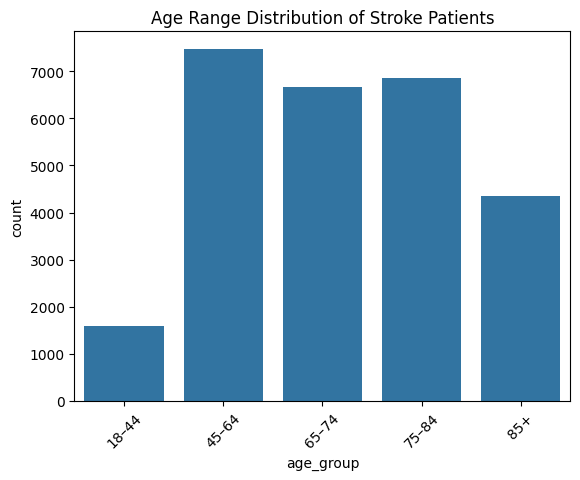

In [179]:
# Age Distribution
age_order = [
    "18–44",
    "45–64",
    "65–74",
    "75–84",
    "85+"
]
sns.countplot(x="age_group", data=complete_df_nn, order=age_order)
plt.title("Age Range Distribution of Stroke Patients")
plt.xticks(rotation=45)
plt.show()

In [180]:
complete_df_nn.to_csv("complete_df_nn.csv")

In [181]:
full_df_nn.to_csv("full_df_nn.csv")

In [182]:
len(complete_df_nn)

26948

In [183]:
len(full_df_nn)

26948